In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

import scipy.stats

/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?


# Helper functions

In [3]:
from affine_math_and_plot_helper import *

# Hyper parameters

In [4]:
RANDOMNESS = False

FIGURE_NAME = 'unifying_math.svg'

# 
SPEED = 0.3

UPWIND_GAMMA_MULTIPLIER = 0.08

SACCADE_THRESHOLD_PROPORTIONAL = 8
SACCADE_THRESHOLD_DERIVATIVE = 3

SMOOTHING_WINDOW = 11

SLOPE_STD = 0.3

dt = 0.01

In [5]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

In [6]:
scenario = 'angled_laminar'

t, wind_direction, wind_speed = get_wind(scenario, RANDOMNESS, SMOOTHING_WINDOW, dt)
raw_circle_course = get_circle_basis(t, RANDOMNESS)
axis_ratio = get_axis_ratio(wind_direction, wind_speed)
color = get_color(scenario)

### Circle trajec and course

In [7]:
raw_circle_xy = get_circle_xy(raw_circle_course)
circle_x, circle_y = get_trajec(raw_circle_course, dt, SPEED)

In [8]:
# ax = layout.axes[('affine', 'circle_trajec')]
# ax.set_aspect('equal')
# braid_analysis_plots.plot_arrowhead_trajectory(circle_x, circle_y, color='black', linewidth=0.75, ax=ax, arrow_length=0.03)
# fifi.mpl_functions.adjust_spines(ax, [])

In [9]:
# ax = layout.axes[('affine', 'wind')]

# #####################################################################################################
# # Wind
# wind_direction_shifted = wrap_angle(wind_direction, midangle='pi')+np.pi
# ax.scatter(t, wind_direction_shifted, s=2, c='orange', linewidths=0, zorder=-1)
# ax.scatter(t, wind_direction_shifted-np.pi/2., s=0.5, c='orange', linewidths=0, zorder=-1)
# ax.set_ylim(0, 2*np.pi)

# xticks = [0, 1, 2, 3, 4, 5]
# xticklabels = np.array(xticks)
# ax.set_xlim(0, 5)
# ax.set_xticks(xticks)
# ax.set_xticklabels([])

# ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
# ax.set_yticklabels(['$0$', '', '', '', '$2\pi$'])

# fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

# ax.tick_params(axis='y', pad=2)
# ax.tick_params(axis='x', pad=2)

# fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
#                                  tick_length=2.5,
#                                  spine_locations={'left': 5, 'bottom': 5},
#                                  linewidth=0.5)
# fifi.mpl_functions.set_fontsize(ax, 6)

# ax.set_rasterization_zorder(0)

In [10]:
ax = layout.axes[('affine', 'course')]
plot_course(ax, t[0:-1:5], raw_circle_course[0:-1:5], None, None, 
                show_labels=False,
                markersizes=[2,3,2],
                spines=['left',])
set_selective_rasterization(ax, 
                            rasterize_markers=['.'], 
                            rasterize_collections=[mcollections.PathCollection, 
                                                   mcollections.PolyCollection], 
                            raster_zorder=-1)
#ax.set_ylabel('Course ($\psi$)')
ax.set_yticklabels(['$-\pi$', '', '', '', '$\pi$'])
#ax.set_xlabel('Time')

[Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, -1.5707963267948966, ''),
 Text(0, 0.0, ''),
 Text(0, 1.5707963267948966, ''),
 Text(0, 3.141592653589793, '$\\pi$')]

In [11]:
ax = layout.axes[('affine', 'blue_ellipse')]
ax.set_aspect('equal')
ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

ax.plot(raw_circle_xy[0,0:npoints_1_rotation:4], raw_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='blue', linewidth=1, zorder=-1)
ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [12]:
affine_warped_course_angle, affine_warped_circle_xy, mean_affine_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=0
                                                                                                                   )

In [13]:
affine_trans_warped_course_angle, affine_trans_warped_circle_xy, mean_affine_trans_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=0.5
                                                                                                                   )
circle_x, circle_y = get_trajec(affine_trans_warped_course_angle, dt, SPEED)

In [14]:
if 1:
    ax = layout.axes[('affine', 'red_ellipse')]
else:
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)

ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

ax.set_aspect('equal')
ax.plot(raw_circle_xy[0,0:npoints_1_rotation], raw_circle_xy[1,0:npoints_1_rotation], '--', color='blue', linewidth=0.5, zorder=-3)
ax.plot(affine_warped_circle_xy[0,0:npoints_1_rotation:4], affine_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='magenta', linewidth=1, zorder=-2)
ax.plot(affine_trans_warped_circle_xy[0,0:npoints_1_rotation:4], affine_trans_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color=color, linewidth=1, zorder=-1)

# draw some reference lines
rotation_angle = mean_angle(wind_direction) + np.pi #/2

c, s = np.cos(rotation_angle), np.sin(rotation_angle)
R = np.array([[c, -s], [s, c]])
S = np.array([[1, 0], [0, 1]])

AM = R@S

xs = np.linspace(0, 1, 10)
yline = np.vstack((xs*0, xs))
xline = np.vstack((xs, xs*0))

ax.plot(yline[0,:], yline[1,:], ':', color='black', linewidth=0.3, zorder=-10)
ax.plot(xline[0,:], xline[1,:], ':', color='black', linewidth=0.3, zorder=-10)

#ax.plot( (AM@yline)[0,:], (AM@yline)[1,:], ':', color='black', linewidth=0.3, zorder=-1)
#ax.plot( (AM@xline)[0,:], (AM@xline)[1,:], ':', color='black', linewidth=0.3, zorder=-1)

#ax.plot( , , '-', color='black', linewidth=0.6, zorder=-1)
x = 0.5*(AM@xline)[0,:]
y = 0.5*(AM@xline)[1,:]
braid_analysis_plots.plot_arrowhead_trajectory(x, y, color='black', linewidth=0.6, ax=ax, arrow_length=0.3)


ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [15]:
if 1:
    ax = layout.axes[('affine', 'magenta_ellipse')]
else:
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)

ix_cross = np.where(np.abs(np.diff(raw_circle_course))>0.2)[0]
npoints_1_rotation = ix_cross[1] - ix_cross[0] + 1

ax.set_aspect('equal')
ax.plot(raw_circle_xy[0,0:npoints_1_rotation], raw_circle_xy[1,0:npoints_1_rotation], '--', color='blue', linewidth=0.5, zorder=-3)
ax.plot(affine_warped_circle_xy[0,0:npoints_1_rotation:4], affine_warped_circle_xy[1,0:npoints_1_rotation:4], '.', markersize=1, color='magenta', linewidth=1, zorder=-2)

# draw some reference lines
rotation_angle = mean_angle(wind_direction) + np.pi #/2

c, s = np.cos(rotation_angle), np.sin(rotation_angle)
R = np.array([[c, -s], [s, c]])
S = np.array([[axis_ratio, 0], [0, 1]])

AM = R@S

xs = np.linspace(0, 1, 10)
yline = np.vstack((xs*0, xs))
xline = np.vstack((xs, xs*0))

ax.plot(yline[0,:], yline[1,:], ':', color='black', linewidth=0.3, zorder=-10)
ax.plot(xline[0,:], xline[1,:], ':', color='black', linewidth=0.3, zorder=-10)

ax.plot( (AM@yline)[0,:], (AM@yline)[1,:], '-', color='black', linewidth=0.6, zorder=-1)
ax.plot( (AM@xline)[0,:], (AM@xline)[1,:], '-', color='black', linewidth=0.6, zorder=-1)

ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [16]:
# ax = layout.axes[('affine', 'trajec')]
# ax.set_aspect('equal')
# braid_analysis_plots.plot_arrowhead_trajectory(circle_x, circle_y, color='black', linewidth=0.76, ax=ax, arrow_length=0.06)
# fifi.mpl_functions.adjust_spines(ax, [])

In [17]:
# ax = layout.axes[('affine', 'affine_course')]
# plot_course(ax, t, raw_circle_course, affine_warped_course_angle, affine_trans_warped_course_angle, 
#             colors=['blue', 'magenta', color],
#             markersizes=[1,2,2],
#                 show_labels=False)
# set_selective_rasterization(ax, 
#                             rasterize_markers=['.'], 
#                             rasterize_collections=[mcollections.PathCollection, 
#                                                    mcollections.PolyCollection], 
#                             raster_zorder=-1)
# #ax.set_ylabel('Course ($\psi$)')
# ax.set_yticklabels(['$-\pi$', '', '', '', '$\pi$'])
# #ax.set_xlabel('Time')

In [18]:
# set_selective_rasterization(ax, 
#                             rasterize_markers=['.'], 
#                             rasterize_collections=[mcollections.PathCollection, 
#                                                    mcollections.PolyCollection], 
#                             raster_zorder=-1)

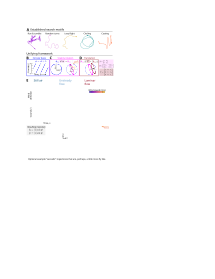

In [19]:
layout.append_figure_to_layer(layout.figures['affine'], 'affine', cleartarget=True)
layout.write_svg(FIGURE_NAME)
from IPython.display import display,SVG
display(SVG(FIGURE_NAME))